## Lab 6 — Transfer Learning, инференс

Грузит веса `best_resnet50_flowers.pt` и историю `history.json`, считает метрики на test-сплите Flowers102.

**Что считаем:** test accuracy, `classification_report` по 102 классам (precision/recall/F1), confusion matrix (log-scale), топ-20 самых путаемых пар, примеры предсказаний с зелёной/красной рамкой.

In [4]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torchvision.models import resnet50
from torch.utils.data import DataLoader

from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


Используемое устройство: cpu


## Кривые обучения

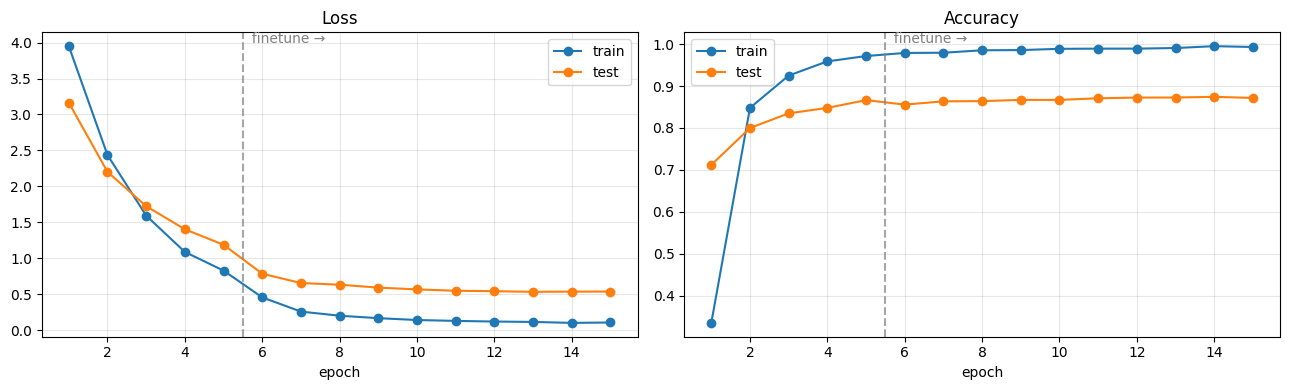

Лучшая test accuracy за всё обучение: 0.8743


In [5]:
with open('history.json') as f:
    history = json.load(f)

epochs = np.arange(1, len(history['train_loss']) + 1)
switch = None
if 'stage' in history and 'finetune' in history['stage']:
    switch = history['stage'].index('finetune') + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(epochs, history['train_loss'], label='train', marker='o')
axes[0].plot(epochs, history['test_loss'],  label='test',  marker='o')
axes[0].set_title('loss'); axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(epochs, history['train_acc'], label='train', marker='o')
axes[1].plot(epochs, history['test_acc'],  label='test',  marker='o')
axes[1].set_title('accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
if switch is not None:
    for ax in axes:
        ax.axvline(switch - 0.5, color='gray', linestyle='--', alpha=0.7)
plt.tight_layout(); plt.show()

print(f'best test acc: {max(history["test_acc"]):.4f}')


## Модель и данные

In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

testset = torchvision.datasets.Flowers102(root='./data', split='test',
                                          download=True, transform=eval_transform)
testloader = DataLoader(testset, batch_size=32, shuffle=False, num_workers=2)

NUM_CLASSES = 102
print(f'test: {len(testset)}')


100%|██████████| 15.0k/15.0k [00:00<00:00, 56.5MB/s]

Тестовых примеров: 6149 | классов: 102


In [7]:
model = resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

state = torch.load('best_resnet50_flowers.pt', map_location=device)
model.load_state_dict(state)
model = model.to(device).eval()


Веса загружены.


## Прогон по test

In [8]:
all_preds, all_labels = [], []

with torch.no_grad():
    for X, y in testloader:
        X = X.to(device)
        logits = model(X)
        all_preds.extend(logits.argmax(1).cpu().numpy().tolist())
        all_labels.extend(y.numpy().tolist())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc = (all_preds == all_labels).mean()
print(f'test acc: {acc:.4f}')


Test accuracy: 0.8743


## Метрики по классам

In [9]:
print(classification_report(all_labels, all_preds, digits=3, zero_division=0))


              precision    recall  f1-score   support

           0      0.548     0.850     0.667        20
           1      0.864     0.950     0.905        40
           2      0.312     0.500     0.385        20
           3      0.421     0.667     0.516        36
           4      0.925     0.822     0.871        45
           5      1.000     1.000     1.000        25
           6      0.655     0.950     0.776        20
           7      0.942     1.000     0.970        65
           8      0.893     0.962     0.926        26
           9      0.923     0.960     0.941        25
          10      0.887     0.701     0.783        67
          11      0.928     0.955     0.941        67
          12      0.879     1.000     0.935        29
          13      0.800     1.000     0.889        28
          14      0.906     1.000     0.951        29
          15      0.654     0.810     0.723        21
          16      0.985     0.985     0.985        65
          17      0.776    

## Confusion matrix

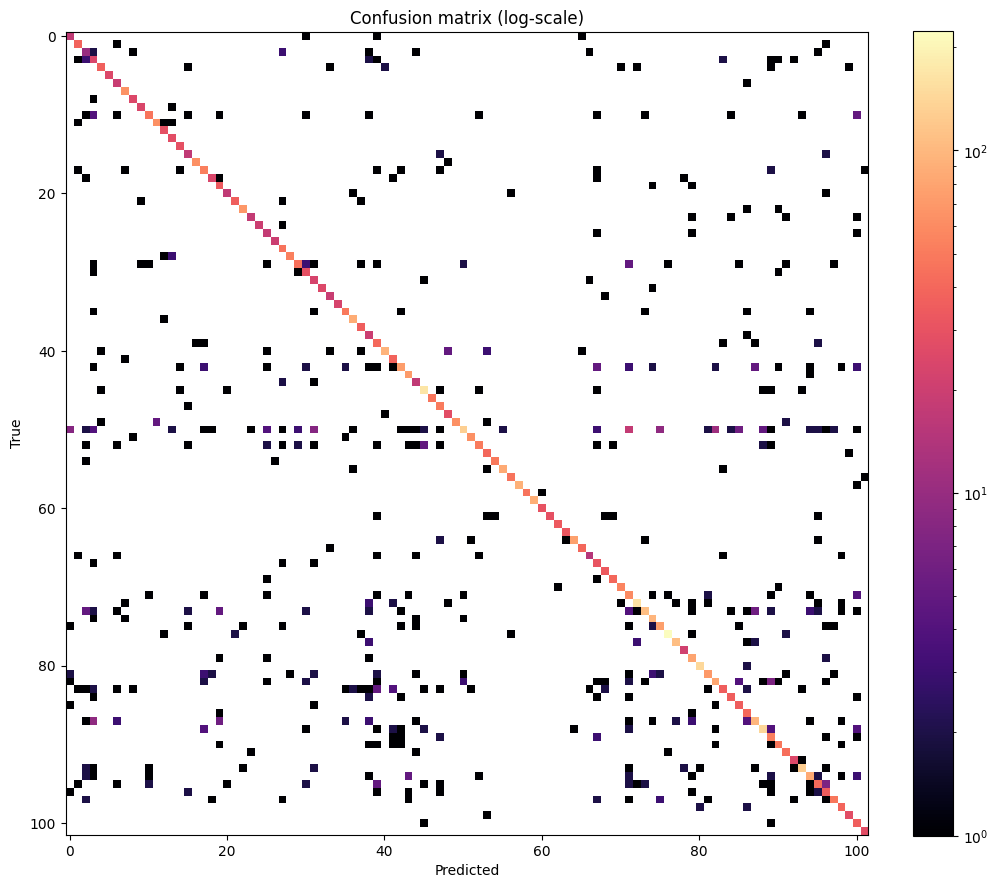

In [10]:
cm = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(cm, cmap='magma', norm=plt.matplotlib.colors.LogNorm(vmin=1, vmax=max(cm.max(), 2)))
ax.set_title('confusion matrix (log)')
ax.set_xlabel('pred'); ax.set_ylabel('true')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()


In [11]:
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
flat_idx = np.argsort(cm_off.ravel())[::-1]
top = []
for idx in flat_idx[:20]:
    i, j = divmod(idx, NUM_CLASSES)
    if cm_off[i, j] == 0:
        break
    top.append((i, j, int(cm_off[i, j])))

print('топ путаемых пар (true -> pred : count):')
for t, p, c in top:
    print(f'  {t:3d} -> {p:3d} : {c}')


Топ путаемых пар (true → pred : count):
  class  50 → class  71 : 18
  class  50 → class  82 : 11
  class  87 → class   3 : 9
  class  50 → class  75 : 9
  class  50 → class  31 : 8
  class  50 → class   0 : 8
  class  95 → class  96 : 7
  class  82 → class  89 : 7
  class  87 → class  19 : 6
  class  50 → class  85 : 6
  class  73 → class  87 : 6
  class  95 → class  39 : 5
  class  40 → class  48 : 5
  class  42 → class  87 : 5
  class  29 → class  71 : 5
  class  94 → class  43 : 5
  class  73 → class  19 : 5
  class  83 → class  39 : 5
  class  49 → class  11 : 5
  class  52 → class  45 : 5


## Примеры предсказаний

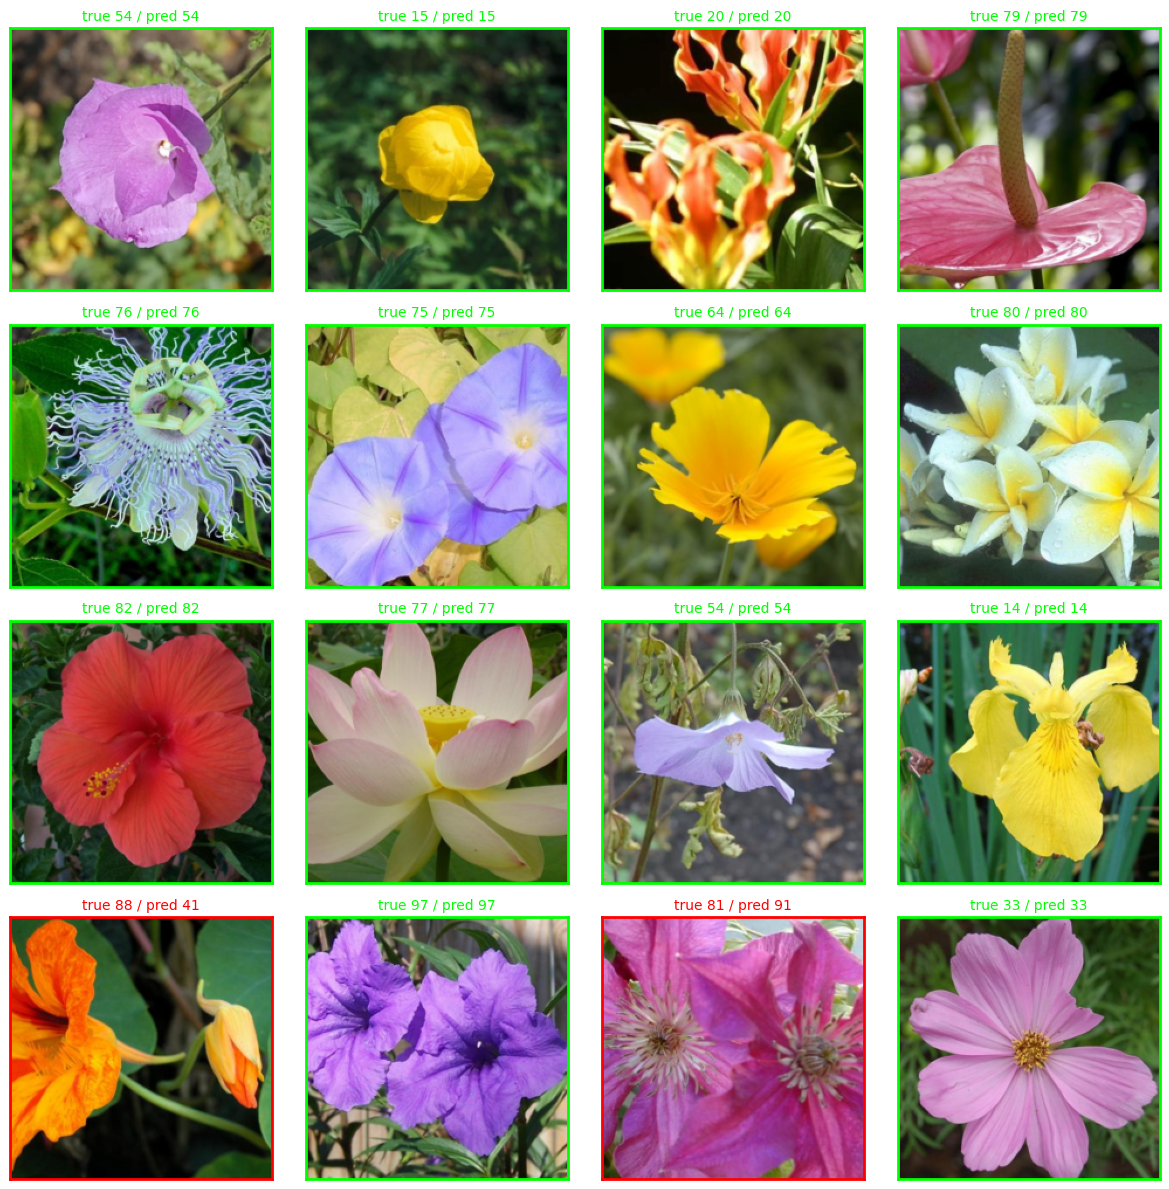

In [12]:
def denorm(t):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (t.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(testset), size=16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for ax, idx in zip(axes.ravel(), sample_idx):
    img, true_lbl = testset[idx]
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device)).argmax(1).item()
    ax.imshow(denorm(img))
    ok = (pred == true_lbl)
    color = 'lime' if ok else 'red'
    ax.set_title(f'true {true_lbl} / pred {pred}', color=color, fontsize=10)
    for spine in ax.spines.values():
        spine.set_color(color); spine.set_linewidth(2)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()
